In [2]:
# STEP 1: LOADING THE STUDENT PERFORMANCE DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Loading the file
df = pd.read_csv('StudentsPerformance.csv')

# We used 'reading score' and 'writing score' for the Bivariate Normal Distribution
x = df['reading score'].values
y = df['writing score'].values

print("Dataset loaded! Here are the first 5 student scores:")
df[['reading score', 'writing score']].head()

Dataset loaded! Here are the first 5 student scores:


,reading score,writing score
0,72,74
1,90,88
2,95,93
3,57,44
4,78,75


In [3]:
# STEP 2: CALCULATING PARAMETERS MANUALLY (NO STATS LIBRARIES)
n = len(x)

# 1. Average scores (Mean)
mu_x = sum(x) / n
mu_y = sum(y) / n

# 2. Standard Deviations (Spread)
std_x = (sum((x - mu_x)**2) / n)**0.5
std_y = (sum((y - mu_y)**2) / n)**0.5

# 3. Correlation (Rho)
covariance = sum((x - mu_x) * (y - mu_y)) / n
rho = covariance / (std_x * std_y)

print(f"Manual Parameters Calculated:")
print(f"Avg Reading Score: {mu_x:.2f}")
print(f"Avg Writing Score: {mu_y:.2f}")
print(f"Correlation (Rho): {rho:.4f}")

Manual Parameters Calculated:
Avg Reading Score: 69.17
Avg Writing Score: 68.05
Correlation (Rho): 0.9546


In [4]:
# STEP 3: APPLYING THE FORMULA TO EACH STUDENT
def bvn_pdf_manual(X_val, Y_val, mx, my, sx, sy, r):
    # Defining pi manually to be safe
    pi_val = 3.141592653589793

    # The 'Constant' front part
    constant = 1 / (2 * pi_val * sx * sy * (1 - r**2)**0.5)

    # The 'Exponent' math part
    z_part = ((X_val - mx)**2 / sx**2) + ((Y_val - my)**2 / sy**2) - (2 * r * (X_val - mx) * (Y_val - my) / (sx * sy))
    exponent = -1 / (2 * (1 - r**2)) * z_part

    return constant * np.exp(exponent)

# Compute the probability density for every single student row
df['Probability_Density'] = bvn_pdf_manual(df['reading score'], df['writing score'], mu_x, mu_y, std_x, std_y, rho)

print("Density calculated for all 1000 students. First 5 results:")
df[['reading score', 'writing score', 'Probability_Density']].head()

Density calculated for all 1000 students. First 5 results:


,reading score,writing score,Probability_Density
0,72,74,0.001861
1,90,88,0.000858
2,95,93,0.000497
3,57,44,0.000052
4,78,75,0.001850


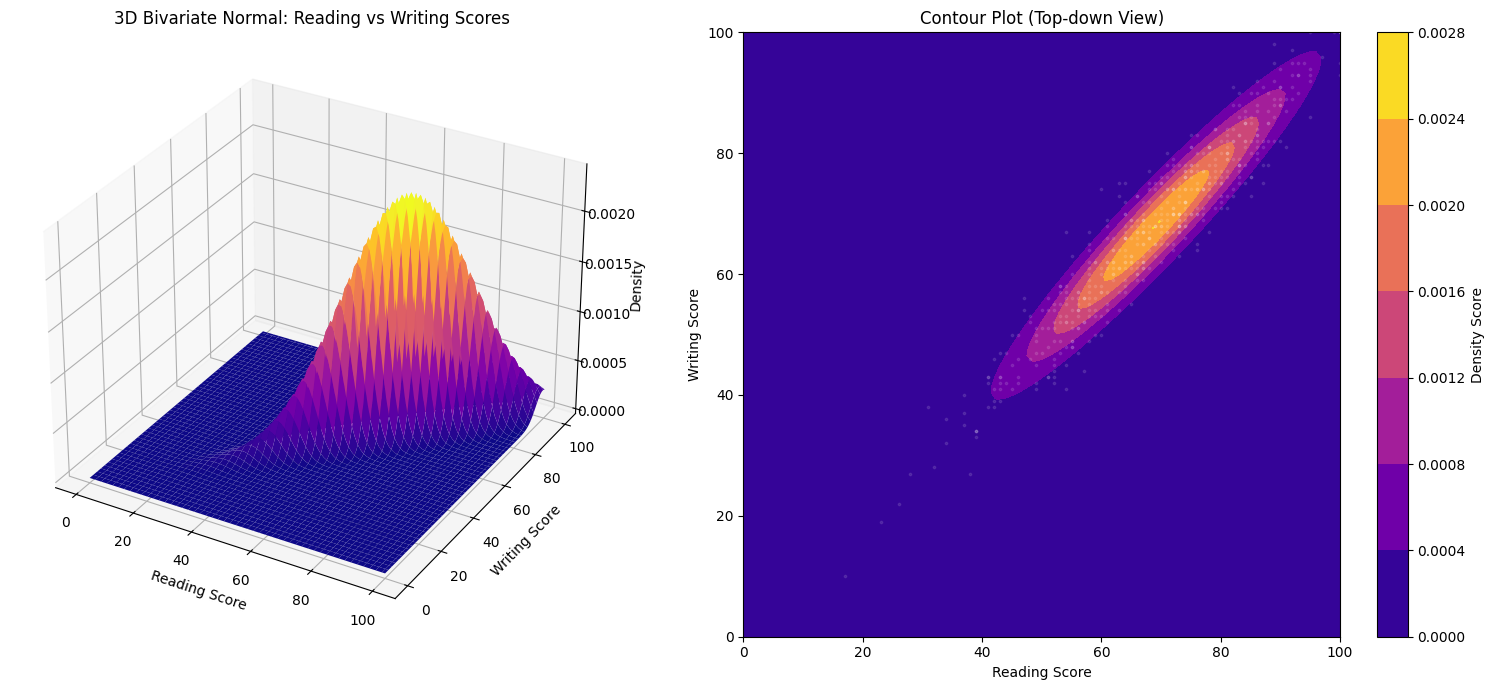

In [7]:
# STEP 4: VISUALIZING THE PDF
# Create a grid covering scores from 0 to 100
x_grid = np.linspace(0, 100, 100)
y_grid = np.linspace(0, 100, 100)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

# Calculate density for the grid to draw the surface
Z_pdf = bvn_pdf_manual(X_mesh, Y_mesh, mu_x, mu_y, std_x, std_y, rho)

fig = plt.figure(figsize=(16, 7))

# A. 3D Surface Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_mesh, Y_mesh, Z_pdf, cmap='plasma')
ax1.set_title('3D Bivariate Normal: Reading vs Writing Scores')
ax1.set_xlabel('Reading Score')
ax1.set_ylabel('Writing Score')
ax1.set_zlabel('Density')

# B. Contour Plot
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X_mesh, Y_mesh, Z_pdf, cmap='plasma')
plt.colorbar(contour, ax=ax2, label='Density Score')
ax2.set_title('Contour Plot (Top-down View)')
ax2.set_xlabel('Reading Score')
ax2.set_ylabel('Writing Score')

# Optional: Add the real students onto the plot to show how they fit the ellipse
ax2.scatter(x[:500], y[:500], color='white', alpha=0.1, s=3)

plt.tight_layout()
plt.show()